# Exploratory Data Analysis — Smartphone RGB Turmeric Adulteration Screening

**Prisha Goswami · Non-Trivial Fellowship**

This notebook is the **EDA gate**: before investing in models, we check whether a
low-cost smartphone RGB pipeline carries any class signal for turmeric adulteration
(pure vs yellow-dye adulterated), and we document the dataset as it flows through the
pipeline.

**Methodology guards**
- **The test set is never touched here.** All signal-detection analyses (colour-vs-ratio,
  PCA) use the **train + val** split only. Peeking at test-set structure to decide how to
  model would bias the final evaluation.
- **Lighting confound.** Raw mean RGB is dominated by the SVI screen colour, not the
  powder. So colour-vs-ratio and the class-separation PCA are computed on the **ambient
  subset** (where colour reflects the sample). The colored-light shots are analysed
  separately to show the illumination protocol expanded feature diversity.
- Features are extracted over the **segmented sample region only** (masked), so background
  never contaminates colour statistics.

Run from the project root.

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ROOT = Path.cwd()
for _ in range(4):
    if (ROOT/"data"/"metadata.csv").exists(): break
    ROOT = ROOT.parent
print("project root:", ROOT)
meta = pd.read_csv(ROOT/"data/metadata.csv", dtype=str).fillna("")
man  = pd.read_csv(ROOT/"data/split/manifest.csv", dtype=str).fillna("")
feat = pd.read_csv(ROOT/"eda/features_trainval.csv")
rank = pd.read_csv(ROOT/"segmentation_review_v2/confidence_ranking.csv")
vf   = pd.read_csv(ROOT/"eda/train_video_frames.csv")

IMG_EXT=(".jpg",".jpeg",".png"); VID_EXT=(".mov",".mp4",".avi")
def rkey(r):
    try: return -float(r.split("_")[0])
    except: return 0
RATIOS = sorted(meta["ratio"].unique(), key=rkey)
rlabel = lambda r: "pure" if r=="100_0" else r.replace("_","/")
FEATURES=["mean_R","mean_G","mean_B","mean_H","mean_S","mean_V",
          "hue_std","sat_std","val_std","bright","contrast"]
print(f"train+val feature rows: {len(feat)}  |  reviewed images: {len(rank)}")

project root: /sessions/zealous-practical-maxwell/mnt/TurmericProject
train+val feature rows: 121  |  reviewed images: 238


## 1. Dataset summary

Verify nothing odd happened in preprocessing: counts per ratio, images vs videos, and
how many illumination conditions each ratio was shot under. (Starch is set aside; the
two quarantined segmentation failures are excluded downstream.)

,ratio,type,images,videos,lightings
0,pure,pure,42,10,6
1,97.5/2.5,yellow_dye,29,7,6
2,95/5,yellow_dye,20,6,6
3,90/10,yellow_dye,18,6,6
4,85/15,yellow_dye,21,4,6
5,80/20,yellow_dye,21,6,6
6,75/25,yellow_dye,21,6,6
7,70/30,yellow_dye,21,6,6
8,60/40,yellow_dye,21,6,6
9,50/50,yellow_dye,24,6,6


Starch reserve (set aside): 81 images / 31 videos across 8 ratios


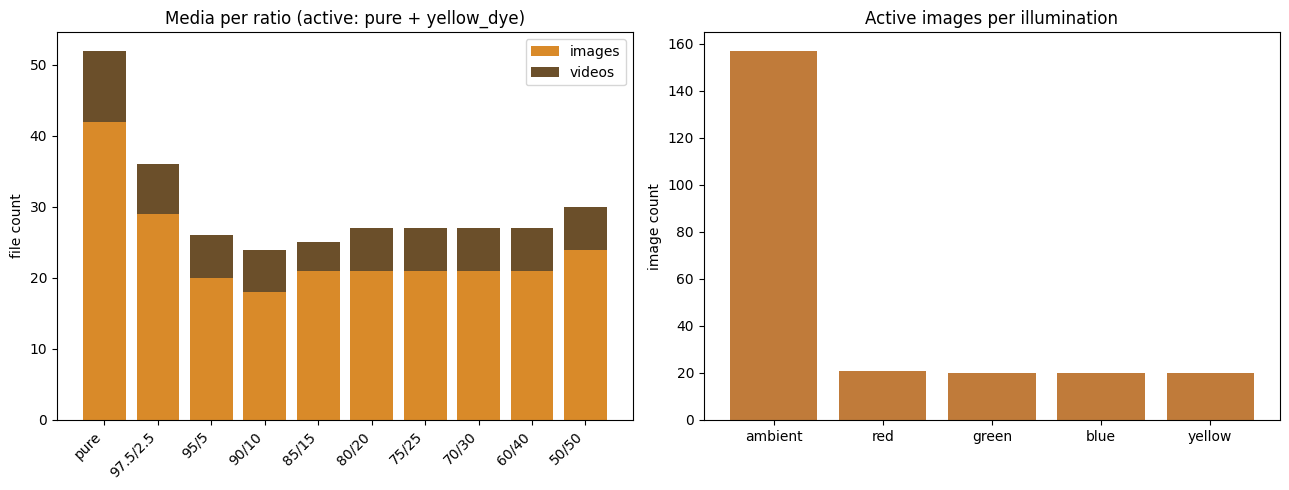

In [2]:
meta["is_img"]=meta["file_name"].str.lower().str.endswith(IMG_EXT)
meta["is_vid"]=meta["file_name"].str.lower().str.endswith(VID_EXT)
meta["type"]=meta["pile_id"].map(lambda p:"pure" if p.startswith("pure") else "yellow_dye" if p.startswith("yellow_dye") else "starch")
active=meta[meta["type"].isin(["pure","yellow_dye"])]
rows=[]
for r in RATIOS:
    s=active[active["ratio"]==r]
    if s.empty: continue
    rows.append(dict(ratio=rlabel(r),type=s["type"].iloc[0],images=int(s["is_img"].sum()),
                     videos=int(s["is_vid"].sum()),lightings=s["illumination_color"].nunique()))
summary=pd.DataFrame(rows); display(summary)
st=meta[meta["type"]=="starch"]
print(f"Starch reserve (set aside): {int(st['is_img'].sum())} images / {int(st['is_vid'].sum())} videos across {st['ratio'].nunique()} ratios")

fig,ax=plt.subplots(1,2,figsize=(13,5)); x=np.arange(len(summary))
ax[0].bar(x,summary["images"],label="images",color="#d98a29")
ax[0].bar(x,summary["videos"],bottom=summary["images"],label="videos",color="#6b4f2a")
ax[0].set_xticks(x); ax[0].set_xticklabels(summary["ratio"],rotation=45,ha="right")
ax[0].set_ylabel("file count"); ax[0].set_title("Media per ratio (active: pure + yellow_dye)"); ax[0].legend()
lc=active[active["is_img"]]["illumination_color"].value_counts()
ax[1].bar(lc.index,lc.values,color="#c07b3a"); ax[1].set_title("Active images per illumination")
ax[1].set_ylabel("image count")
plt.tight_layout(); plt.show()

**Read.** The nine yellow-dye ratios are covered from 97.5/2.5 (near-pure) down to
50/50, plus pure. Note the **ambient shots are sparse for several ratios** — most
adulterated samples were shot under colored SVI light, which matters for the colour
analysis below.

## 2. Segmentation statistics

We spent significant effort on illumination-independent segmentation, so quantify it.
Diagnostics come from the review of all 238 images.

Reviewed: 238 | hard fallbacks: 0 | quarantined failures: 2 | borderline flags: 20
Automatic segmentation isolated the sample in 100.0% of images (0 fallbacks); 99.2% usable after quarantine.
ROI area: median 4.1% of frame, mean 4.9%.


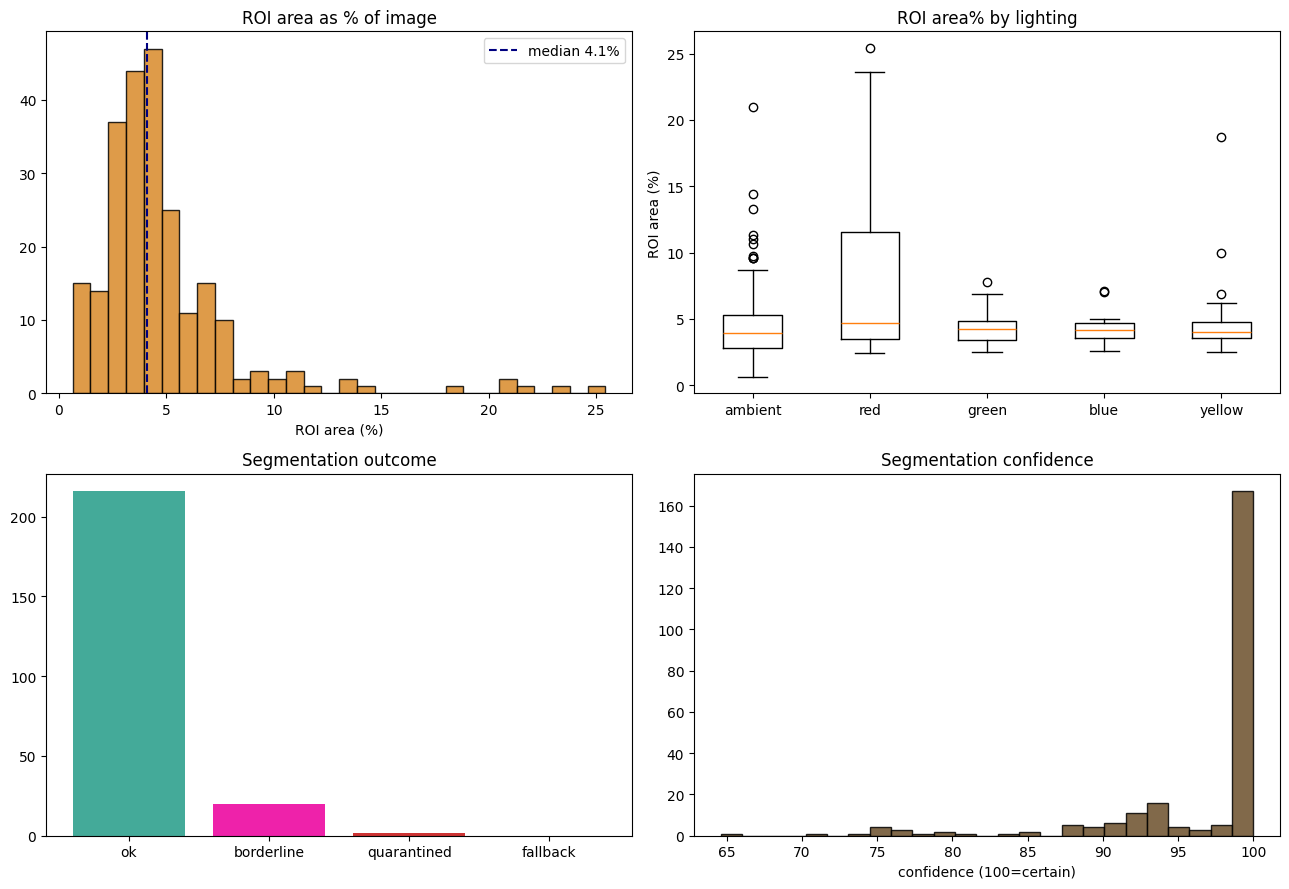

In [3]:
n_rev=len(rank); n_fb=int((rank["ok"]==0).sum()); n_fail=2
n_border=int((rank["near_fallback"]==1).sum()); usable=n_rev-n_fail
print(f"Reviewed: {n_rev} | hard fallbacks: {n_fb} | quarantined failures: {n_fail} | "
      f"borderline flags: {n_border}")
print(f"Automatic segmentation isolated the sample in {100*(n_rev-n_fb)/n_rev:.1f}% of images "
      f"(0 fallbacks); {100*usable/n_rev:.1f}% usable after quarantine.")
print(f"ROI area: median {rank['area_frac'].median()*100:.1f}% of frame, mean {rank['area_frac'].mean()*100:.1f}%.")

fig,ax=plt.subplots(2,2,figsize=(13,9))
ax[0,0].hist(rank["area_frac"]*100,bins=30,color="#d98a29",edgecolor="k",alpha=.85)
ax[0,0].axvline(rank["area_frac"].median()*100,color="navy",ls="--",label=f"median {rank['area_frac'].median()*100:.1f}%")
ax[0,0].set_title("ROI area as % of image"); ax[0,0].set_xlabel("ROI area (%)"); ax[0,0].legend()
order=["ambient","red","green","blue","yellow","cycling"]
data=[rank[rank["lighting"]==l]["area_frac"].values*100 for l in order if (rank["lighting"]==l).any()]
labs=[l for l in order if (rank["lighting"]==l).any()]
ax[0,1].boxplot(data,tick_labels=labs); ax[0,1].set_title("ROI area% by lighting"); ax[0,1].set_ylabel("ROI area (%)")
q={"ok":usable-n_border,"borderline":n_border,"quarantined":n_fail,"fallback":n_fb}
ax[1,0].bar(q.keys(),q.values(),color=["#4a9","#e2a","#c33","#777"]); ax[1,0].set_title("Segmentation outcome")
ax[1,1].hist(rank["confidence"],bins=25,color="#6b4f2a",edgecolor="k",alpha=.85)
ax[1,1].set_title("Segmentation confidence"); ax[1,1].set_xlabel("confidence (100=certain)")
plt.tight_layout(); plt.show()

**Headline result.** *Automatic, illumination-independent segmentation isolated the
turmeric sample in 100% of images (0 fallbacks); 99.2% remained usable after quarantining
two objectively failed ROIs.* Border-touch and small-mound cases are flagged as borderline
but were confirmed usable on inspection.

## 3. Colour vs adulteration ratio (ambient only)

Does the sample's colour shift with dye fraction? Computed on ambient images so colour
reflects powder, not screen. **Caveat: ambient n per ratio is uneven and small for several
ratios — treat intermediate points cautiously.**

ambient n per ratio: {'pure': 22, '97.5/2.5': 2, '95/5': 10, '90/10': 2, '85/15': 11, '80/20': 2, '75/25': 11, '70/30': 2, '60/40': 10, '50/50': 2}


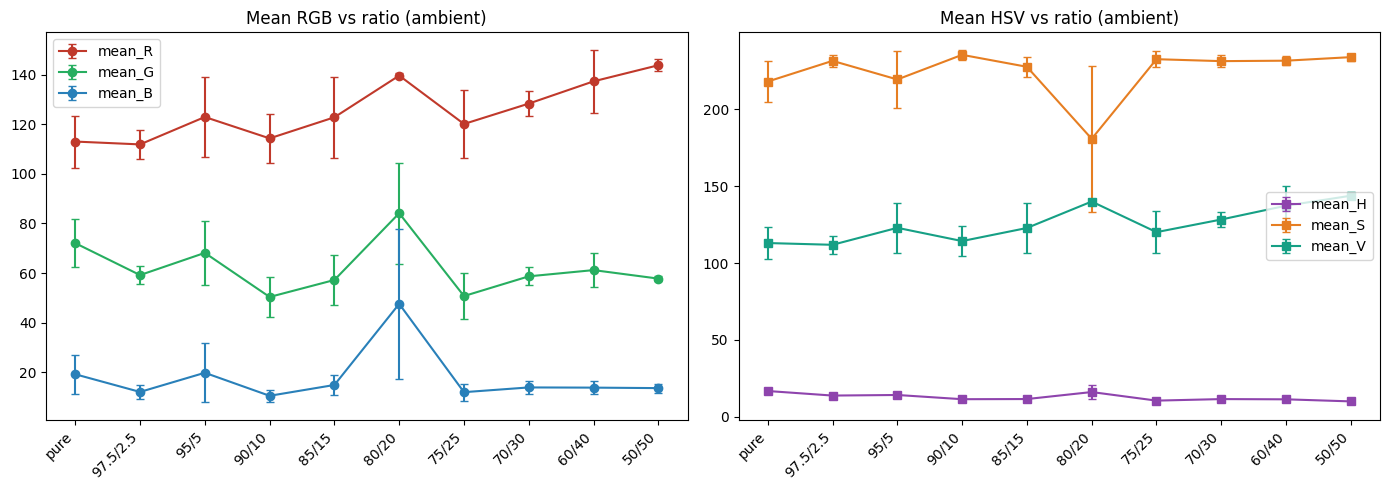

In [4]:
amb=feat[feat["illum"]=="ambient"]
amb_ratios=[r for r in RATIOS if (amb["ratio"]==r).any()]
xr=np.arange(len(amb_ratios)); xl=[rlabel(r) for r in amb_ratios]
n=[int((amb["ratio"]==r).sum()) for r in amb_ratios]
print("ambient n per ratio:", dict(zip(xl,n)))
def ser(c): return (np.array([amb[amb["ratio"]==r][c].mean() for r in amb_ratios]),
                    np.array([amb[amb["ratio"]==r][c].std(ddof=0) for r in amb_ratios]))
fig,ax=plt.subplots(1,2,figsize=(14,5))
for c,col in [("mean_R","#c0392b"),("mean_G","#27ae60"),("mean_B","#2980b9")]:
    m,s=ser(c); ax[0].errorbar(xr,m,yerr=s,marker="o",capsize=3,label=c,color=col)
ax[0].set_xticks(xr); ax[0].set_xticklabels(xl,rotation=45,ha="right"); ax[0].set_title("Mean RGB vs ratio (ambient)"); ax[0].legend()
for c,col in [("mean_H","#8e44ad"),("mean_S","#e67e22"),("mean_V","#16a085")]:
    m,s=ser(c); ax[1].errorbar(xr,m,yerr=s,marker="s",capsize=3,label=c,color=col)
ax[1].set_xticks(xr); ax[1].set_xticklabels(xl,rotation=45,ha="right"); ax[1].set_title("Mean HSV vs ratio (ambient)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Read.** Mean **red** and **saturation** trend upward as dye fraction increases
(pure R≈113 → 50/50 R≈144; S≈218 → ≈232), consistent with yellow dye brightening and
saturating the powder. The trend is suggestive rather than clean — the 80/20 spike is an
n=2 artifact — but it points in a physically sensible direction.

## 4. PCA — the signal gate

If pure and adulterated separate *without* using labels, that is encouraging. Left: all
train+val coloured by lighting (expect lighting to dominate). Right: **ambient only,
coloured by class** — the actual gate.

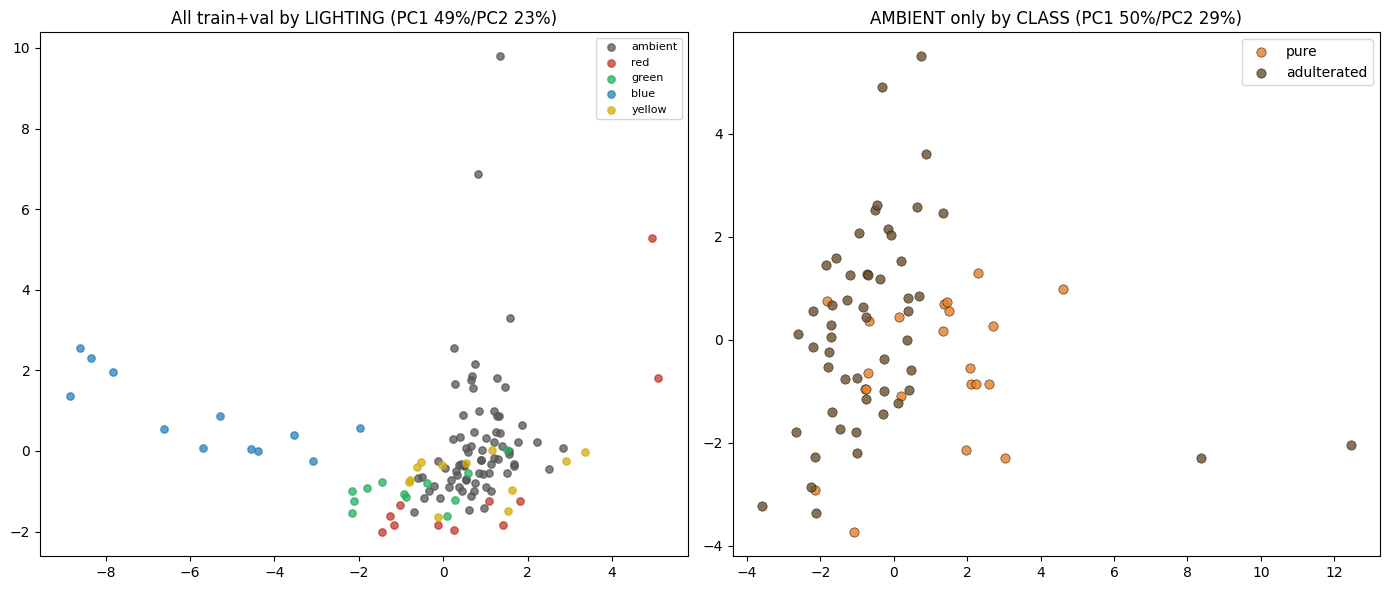

In [5]:
X=StandardScaler().fit_transform(feat[FEATURES].values)
pa=PCA(2).fit(X); Z=pa.transform(X)
fig,ax=plt.subplots(1,2,figsize=(14,6))
cmap={"ambient":"#555","red":"#c0392b","green":"#27ae60","blue":"#2980b9","yellow":"#d4ac0d","cycling":"#8e44ad"}
for l,c in cmap.items():
    m=(feat["illum"]==l).values
    if m.any(): ax[0].scatter(Z[m,0],Z[m,1],s=28,c=c,label=l,alpha=.75)
ax[0].set_title(f"All train+val by LIGHTING (PC1 {pa.explained_variance_ratio_[0]*100:.0f}%/PC2 {pa.explained_variance_ratio_[1]*100:.0f}%)"); ax[0].legend(fontsize=8)
Xa=StandardScaler().fit_transform(amb[FEATURES].values); pb=PCA(2).fit(Xa); Za=pb.transform(Xa)
for cl,c,lab in [(0,"#e67e22","pure"),(1,"#6b4f2a","adulterated")]:
    m=amb["cls"].values==cl
    ax[1].scatter(Za[m,0],Za[m,1],s=45,c=c,label=lab,alpha=.8,edgecolors="k",linewidths=.4)
ax[1].set_title(f"AMBIENT only by CLASS (PC1 {pb.explained_variance_ratio_[0]*100:.0f}%/PC2 {pb.explained_variance_ratio_[1]*100:.0f}%)"); ax[1].legend()
plt.tight_layout(); plt.show()

**Read.** Lighting is the dominant axis of variation overall (blue-lit shots split
off entirely) — which is *why* the robustness study matters. On the ambient subset, pure
and adulterated show **partial separation** (pure concentrates toward positive PC1,
adulterated spreads wider) with real overlap. Unsupervised structure is weak-but-present:
enough to justify supervised baselines, not so clean that the problem is trivial.

## 5. Lighting analysis — did colored light add diversity?

The SVI colored-light protocol was meant to expand real-world variability. Compare the
feature spread of ambient vs colored shots.

avg per-feature std — ambient 10.3 vs colored 27.7  (x2.7)


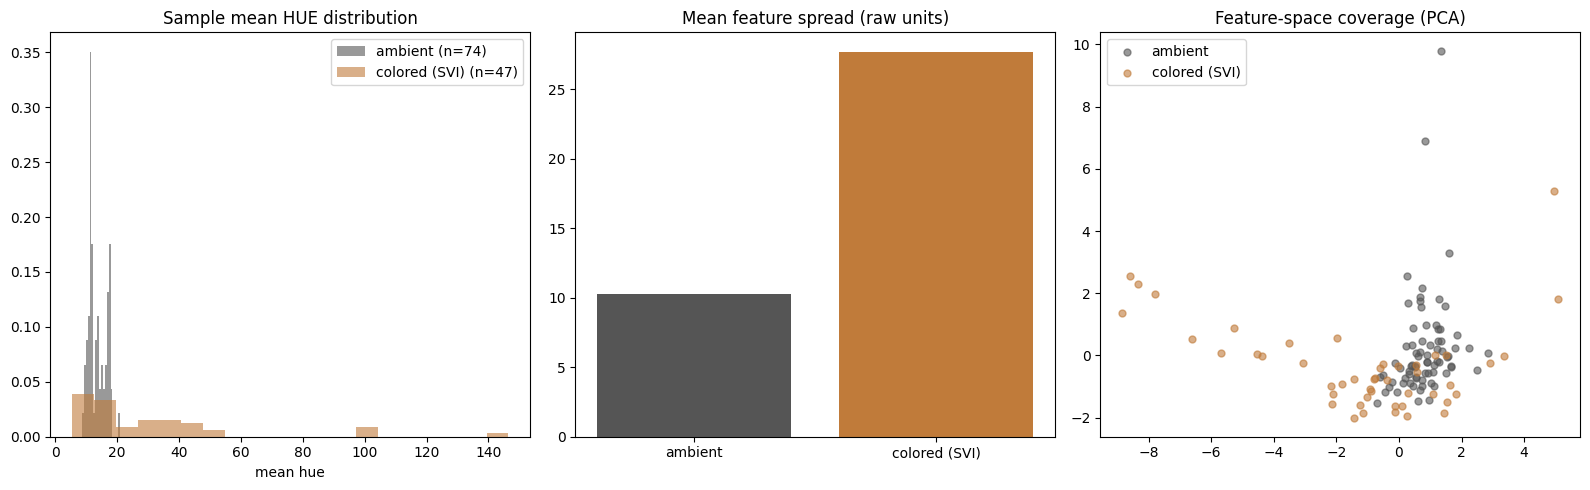

In [6]:
feat["light_group"]=feat["illum"].map(lambda x:"ambient" if x=="ambient" else "colored (SVI)")
amb_std=feat[feat["light_group"]=="ambient"][FEATURES].std().mean()
col_std=feat[feat["light_group"]=="colored (SVI)"][FEATURES].std().mean()
print(f"avg per-feature std — ambient {amb_std:.1f} vs colored {col_std:.1f}  (x{col_std/amb_std:.1f})")
fig,ax=plt.subplots(1,3,figsize=(16,5))
for g,c in [("ambient","#555"),("colored (SVI)","#c07b3a")]:
    d=feat[feat["light_group"]==g]["mean_H"]; ax[0].hist(d,bins=20,alpha=.6,label=f"{g} (n={len(d)})",color=c,density=True)
ax[0].set_title("Sample mean HUE distribution"); ax[0].set_xlabel("mean hue"); ax[0].legend()
ax[1].bar(["ambient","colored (SVI)"],[amb_std,col_std],color=["#555","#c07b3a"]); ax[1].set_title("Mean feature spread (raw units)")
for g,c in [("ambient","#555"),("colored (SVI)","#c07b3a")]:
    m=(feat["light_group"]==g).values; ax[2].scatter(Z[m,0],Z[m,1],s=25,c=c,label=g,alpha=.6)
ax[2].set_title("Feature-space coverage (PCA)"); ax[2].legend()
plt.tight_layout(); plt.show()

**Read.** Colored-light shots cover **~2.7× the feature spread** of ambient shots and
occupy regions of PCA space ambient never reaches. The colored-illumination protocol
demonstrably expanded diversity — the basis for the degradation/robustness study, and a
reason segmentation had to be illumination-independent.

## 6. Class balance through the pipeline

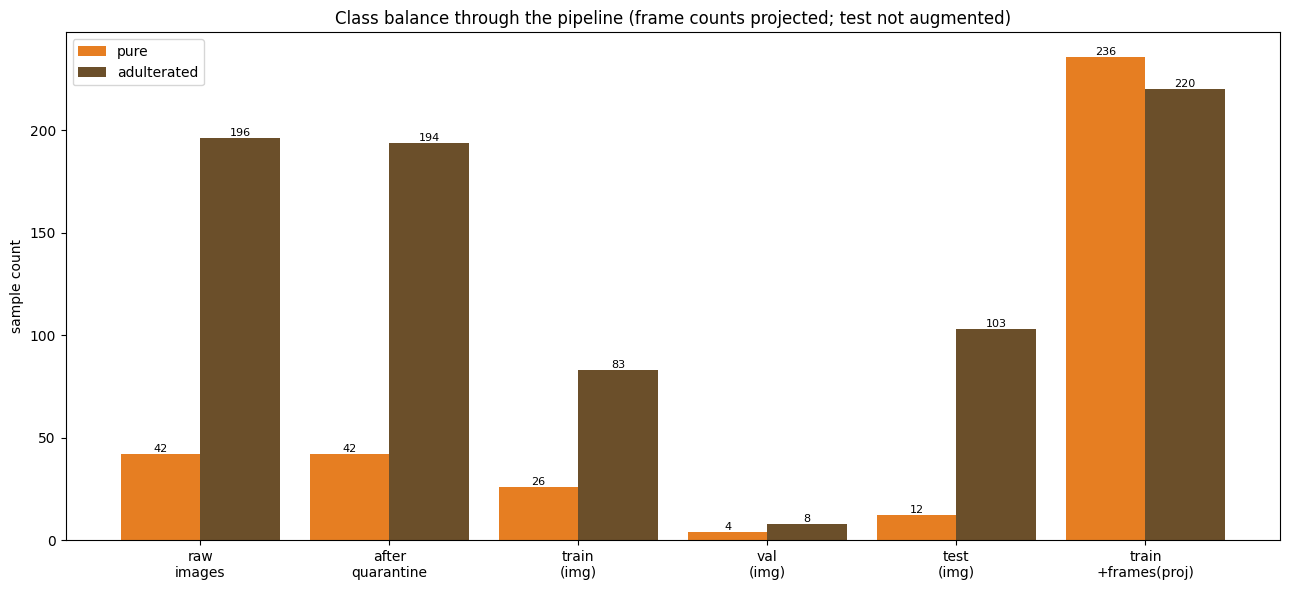

Projected train after frame extraction: pure 236, adulterated 220


In [7]:
raw=meta[meta["is_img"] & (meta["type"]!="starch")]
raw_p=int((raw["type"]=="pure").sum()); raw_a=int((raw["type"]=="yellow_dye").sum())
man["is_img"]=man["rel_path"].str.lower().str.endswith(IMG_EXT); mi=man[man["is_img"]]
sc=lambda sp,cl:int(((mi["split"]==sp)&(mi["cls"]==str(cl))).sum())
proj_p=int((vf[vf.cls==0]["frames"]//15).sum()); proj_a=int((vf[vf.cls==1]["frames"]//60).sum())
stages=["raw\nimages","after\nquarantine","train\n(img)","val\n(img)","test\n(img)","train\n+frames(proj)"]
pv=[raw_p,raw_p,sc("train",0),sc("val",0),sc("test",0),sc("train",0)+proj_p]
av=[raw_a,raw_a-2,sc("train",1),sc("val",1),sc("test",1),sc("train",1)+proj_a]
fig,ax=plt.subplots(figsize=(13,6)); x=np.arange(len(stages)); w=.42
ax.bar(x-w/2,pv,w,label="pure",color="#e67e22"); ax.bar(x+w/2,av,w,label="adulterated",color="#6b4f2a")
for i,(p,a) in enumerate(zip(pv,av)):
    ax.text(i-w/2,p,str(p),ha="center",va="bottom",fontsize=8); ax.text(i+w/2,a,str(a),ha="center",va="bottom",fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(stages); ax.set_ylabel("sample count")
ax.set_title("Class balance through the pipeline (frame counts projected; test not augmented)"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Projected train after frame extraction: pure {sc('train',0)+proj_p}, adulterated {sc('train',1)+proj_a}")

**Read.** Raw images are imbalanced (~42 pure : 194 adulterated after quarantine). The
planned **asymmetric frame sampling** (pure videos every 15 frames, adulterated every 60)
lifts the training set to ≈**236 pure : 220 adulterated** — near balance — without touching
val/test. Caveat: video frames are temporally correlated, and pure diversity is still only
5 physical piles, so `class_weight='balanced'` and pile-aware reporting remain necessary.

## Signal-gate verdict

**PASS — proceed to baselines.**

- Segmentation is reliable (100% located, 99.2% usable), so downstream colour features are trustworthy.
- Colour statistics show a physically sensible trend (red & saturation rise with dye).
- Unsupervised PCA on ambient shows **partial pure/adulterated separation** — signal is present but not trivial.
- Lighting is the dominant variance axis (≈2.7× spread), confirming the colored-light protocol added the real-world diversity the robustness study depends on.

This clears the gate: there is enough class signal to justify Tier-1→3 models. The honest
framing for the report is that the *easy* signal is entangled with illumination, which is
precisely the phenomenon the degradation study is designed to characterise. No need to stop
and re-scope.

*Reminder: all analyses above use train+val only; the test set remains sealed for final reporting.*